In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
N = 100      # sweeps
SEED = 0    # dynamics RNG

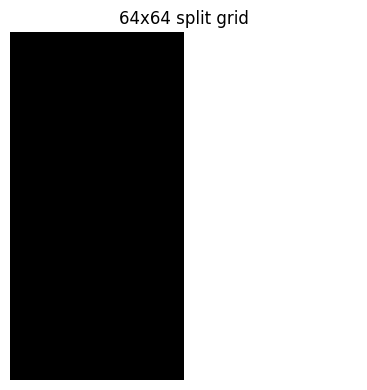

In [13]:
def make_split(size=64):
    """Left half 0 (black), right half 1 (white). Vertical boundary in the middle."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(64)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title("64x64 split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

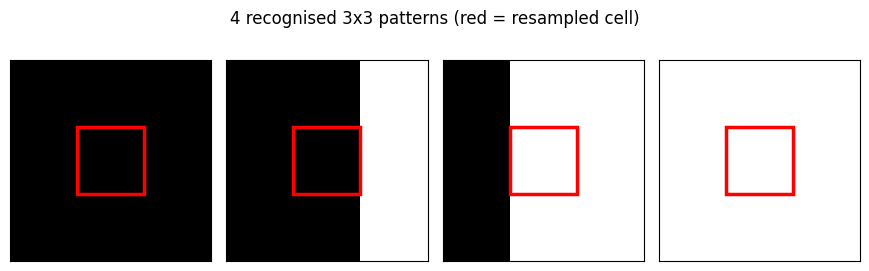

In [14]:
def win_key(w):
    """All nine cells of a 3x3 window, row-major."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """The set of complete 3x3 patterns that occur in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False,
                                   edgecolor="red", lw=2.5))
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns (red = resampled cell)")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [15]:
def step_seq(field, seen, rng):
    """Sequential sweep, sites in random order. For each cell, try both centre
    values; keep whichever make the whole 3x3 a recognised pattern.
    Both work -> coin flip. Neither works -> leave the cell alone."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    unresolved = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2].copy()
        ok = []
        for v in (0, 1):
            w[1, 1] = v
            if win_key(w) in seen:
                ok.append(v)
        if len(ok) == 1:
            field[r, c] = ok[0]
        elif len(ok) == 2:
            field[r, c] = int(rng.random() < 0.5)
        else:
            unresolved += 1
    return field, unresolved


def run(field, seen, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. `field` itself is never modified.
    Prints only when the numbers change."""
    rng = np.random.default_rng(seed)
    original = field.copy()
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, unresolved = step_seq(f, seen, rng)
        state = (int((f != original).sum()), unresolved)
        if verbose and state != prev:
            print(f"  sweep {t:5d}: differing = {state[0]:5d}   unresolved = {state[1]}")
            prev = state
    return f

In [16]:
final_clean = run(grid, seen, verbose=False)
print("fixed point:", np.array_equal(final_clean, grid))

fixed point: True


Noise 5.00%, unrecognised windows left alone:
  sweep     1: differing =   134   unresolved = 862
  sweep     2: differing =   134   unresolved = 408


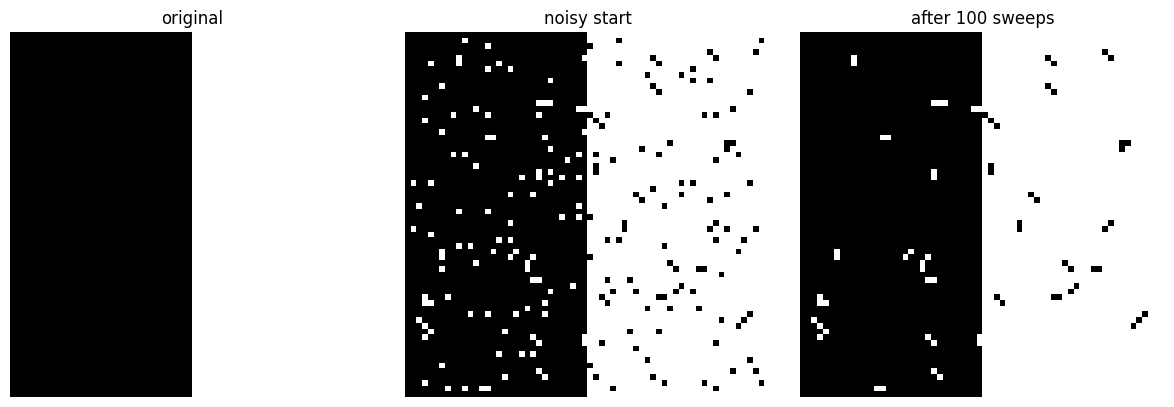

In [17]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.05
NOISE_SEED = 1

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
print(f"Noise {FRAC:.2%}, unrecognised windows left alone:")
final_noisy = run(noisy, seen)
plot_three(grid, noisy, final_noisy, N)

So how this code works is we add a fair bit of noise in this case, and we sweep one by one. We look at every single point, and we check its neighbors, and we flip until we find a pattern we recognize. If we never recognize the pattern, it doesn't change. The flaw we have here is we do not consider side neighbors, and so as we can see, chunks or noise particles that are connected by over Two to three to four pieces do not change, and you can actually guess what ones they're going to be. So a fix I could do here is maybe flip all 8 until we recognize the pattern. I'm not sure how plausible that is.Something we could try is to look at the grid, see which one of our recognized patterns it is close to, and then change it to that.  

Here I have gone with the nearest pattern repair method. 

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
N = 50       # number of sweeps
SEED = 0     # RNG for sweep order
size = 20  # grid size

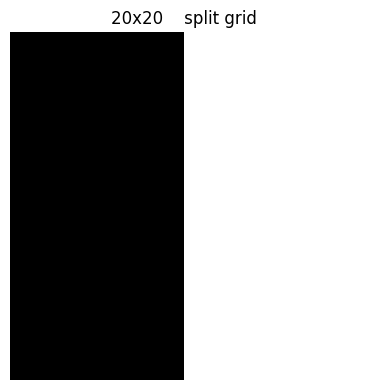

In [16]:
def make_split(size):
    """Left half black (0), right half white (1). One vertical boundary."""
    g = np.zeros((size, size), dtype=int)
    g[:, size // 2:] = 1
    return g


grid = make_split(size)

plt.figure(figsize=(4, 4))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.title(f"{size}x{size}    split grid")
plt.axis("off")
plt.tight_layout()
plt.show()

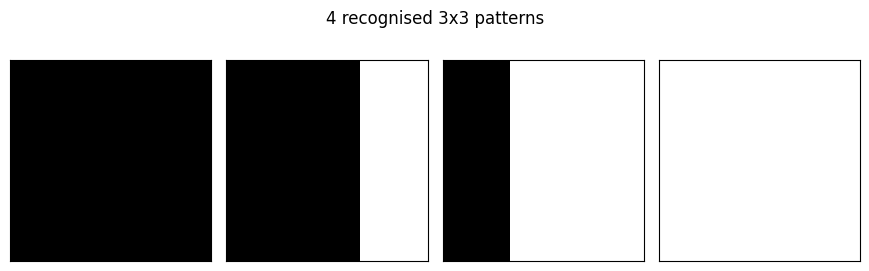

In [17]:
def win_key(w):
    """The nine cells of a 3x3 window, row-major, as a tuple."""
    return tuple(int(x) for x in w.ravel())


def build_windows(grid):
    """Every complete 3x3 pattern that occurs in the grid."""
    seen = set()
    rows, cols = grid.shape
    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            seen.add(win_key(grid[r - 1:r + 2, c - 1:c + 2]))
    return seen


def plot_windows(seen):
    items = sorted(seen)
    fig, axes = plt.subplots(1, len(items), figsize=(2.2 * len(items), 2.8))
    axes = np.atleast_1d(axes)
    for ax, w in zip(axes, items):
        ax.imshow(np.array(w, dtype=float).reshape(3, 3), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{len(items)} recognised 3x3 patterns")
    plt.tight_layout()
    plt.show()


seen = build_windows(grid)
plot_windows(seen)

In [18]:
def pattern_array(seen):
    """Recognised patterns as a (P, 3, 3) int array, in sorted order."""
    return np.array([np.array(p, dtype=int).reshape(3, 3) for p in sorted(seen)])


PATTERNS = pattern_array(seen)


def nearest_pattern(w, patterns):
    """The recognised pattern closest to window w (fewest differing cells).
    Ties: change the centre as little as possible, then lowest sorted order."""
    diffs = (patterns != w).reshape(len(patterns), -1).sum(axis=1)   # Hamming distances
    cands = np.where(diffs == diffs.min())[0]
    if len(cands) > 1:                                               # tie-break 1
        centre_change = (patterns[cands, 1, 1] != w[1, 1]).astype(int)
        cands = cands[centre_change == centre_change.min()]
    return patterns[cands[0]]                                        # tie-break 2: sorted order


def step_seq(field, patterns, rng):
    """One sweep. Visit interior cells in random order; replace each 3x3 window
    with its nearest recognised pattern. Returns (field, cells_changed)."""
    rows, cols = field.shape
    sites = [(r, c) for r in range(1, rows - 1) for c in range(1, cols - 1)]
    changed = 0
    for i in rng.permutation(len(sites)):
        r, c = sites[i]
        w = field[r - 1:r + 2, c - 1:c + 2]
        new = nearest_pattern(w, patterns)
        if not np.array_equal(new, w):
            changed += int((new != w).sum())
            field[r - 1:r + 2, c - 1:c + 2] = new
    return field, changed


def run(field, patterns, sweeps=N, seed=SEED, verbose=True):
    """Returns the final field. The input `field` is never modified.
    Prints only when the number of changes moves."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    prev = None
    for t in range(1, sweeps + 1):
        f, changed = step_seq(f, patterns, rng)
        if verbose and changed != prev:
            print(f"  sweep {t:5d}: cells changed = {changed}")
            prev = changed
    return f

  sweep     1: cells changed = 13
  sweep     2: cells changed = 0
still differing from original: 0


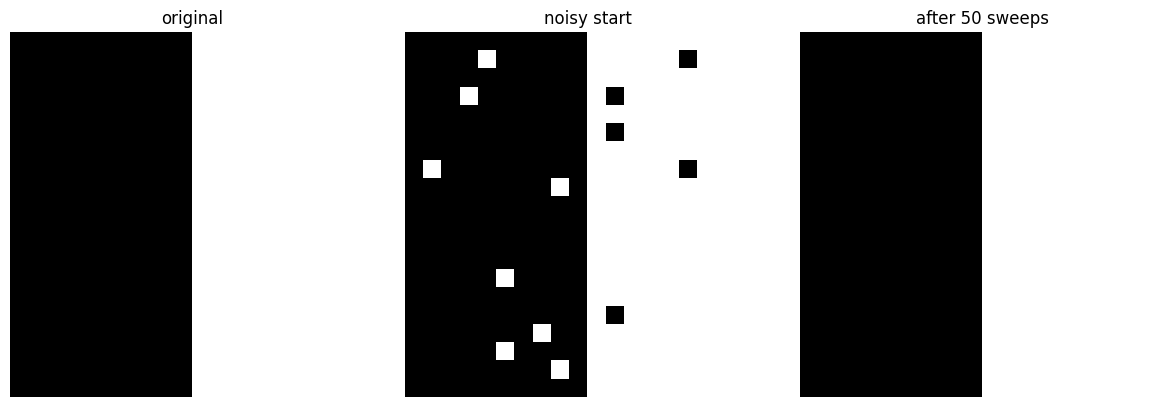

In [19]:
def add_noise(field, frac, seed=1):
    """Flip a fraction of the interior cells at random."""
    rng = np.random.default_rng(seed)
    f = field.copy()
    rows, cols = f.shape
    mask = np.zeros_like(f, dtype=bool)
    mask[1:-1, 1:-1] = rng.random((rows - 2, cols - 2)) < frac
    f[mask] ^= 1
    return f


def plot_three(original, start, final, sweeps):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    for a, (img, t) in zip(ax, [(original, "original"),
                                (start, "noisy start"),
                                (final, f"after {sweeps} sweeps")]):
        a.imshow(img, cmap="gray", vmin=0, vmax=1)
        a.set_title(t)
        a.axis("off")
    plt.tight_layout()
    plt.show()


FRAC = 0.05
NOISE_SEED = 15

noisy = add_noise(grid, frac=FRAC, seed=NOISE_SEED)
final_noisy = run(noisy, PATTERNS)
print("still differing from original:", int((final_noisy != grid).sum()))
plot_three(grid, noisy, final_noisy, N)

differing cells per column: []
column counts: []


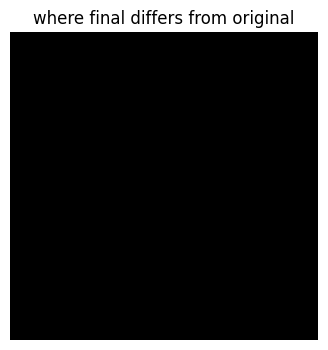

In [20]:
diff = (final_noisy != grid)
print("differing cells per column:", np.where(diff.sum(axis=0) > 0)[0])
print("column counts:", diff.sum(axis=0)[diff.sum(axis=0) > 0])

plt.figure(figsize=(4, 4))
plt.imshow(diff, cmap="gray")
plt.title("where final differs from original")
plt.axis("off")
plt.show()

Repair is perfect, but at a certain point we do see some shift at the boundary. What is also quite interesting as we increase The fraction of cells flipped We see almost a wave pattern reversal. 

Takeaways so far: the center only has a repair radius of 1, so we do tend to get stuck. The whole window nearest pattern works great. But it can cause slight drift, so I will have to try and figure out how to fix that. 

So, full recap so far: first algorithm only flips the center. If you flip and it becomes a recognized pattern, we go with that pattern. If not, nothing changes. 
Second algorithm does the whole window. We compare the current and a pattern that we recognize, and we see the difference between them. I believe it's called the Hamming distance, and whatever pattern we recognize as closer, we will replace it with that. 
Algorithm that we know will try: we'll combine both, so we flip the center to see if that works. If not, fall back to the nearest pattern. 